# Geometric Visualization of Eigenvalues and Eigenvectors

In the previous exercise, we learned how to compute the eigenvalues and eigenvectors of an $n \times n$ matrix using Python.  
In this first part of the notebook, we will visualize these results in order to better understand the geometric meaning of eigenvectors and linear transformations.

First, we import the `numpy` library, which allows us to work with matrices and vectors.

In [12]:
import numpy as np

Now we define the following matrix $B$:

In [13]:
B = np.array([[1, -2], [3, -4]])
print("B = \n", B)

B = 
 [[ 1 -2]
 [ 3 -4]]


Next, we compute the eigenvalues and eigenvectors of the matrix using the function `np.linalg.eig()`.

In [14]:
eigenwerte, eigenvektoren = np.linalg.eig(B)
l1, l2 = eigenwerte
print("Eigenwerte lambda1:", l1) # lambda1 = -1 
print("Eigenwerte lambda2:", l2) # lambda2 = -2

v1, v2 = eigenvektoren[:, 0], eigenvektoren[:, 1]
print("Eigenvektoren v1:\n", v1) 
print("Eigenvektoren v2:\n", v2)

Eigenwerte lambda1: -0.9999999999999996
Eigenwerte lambda2: -2.0
Eigenvektoren v1:
 [0.70710678 0.70710678]
Eigenvektoren v2:
 [0.5547002  0.83205029]


Finally, we visualize the eigenvectors $v_1$ and $v_2$ together with the transformed vectors $Bv_1$ and $Bv_2$.  
For the visualization, we use the `matplotlib` library, which allows us to create 2D graphical representations of vectors in the Cartesian plane.

More specifically, we use the function `plt.quiver()`, which draws arrows starting from the origin and pointing toward the coordinates of each vector.  
This makes it possible to compare the original eigenvectors with their transformed versions after applying the matrix $B$.


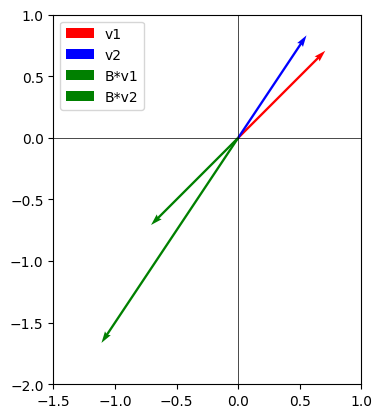

In [8]:
import matplotlib.pyplot as plt

origin = np.array([0, 0])

plt.quiver(*origin, *v1, angles='xy', scale_units='xy', scale=1, color='r', label="v1")
plt.quiver(*origin, *v2, angles='xy', scale_units='xy', scale=1, color='b', label="v2")
plt.quiver(*origin, *w1, angles='xy', scale_units='xy', scale=1, color='g', label="B*v1")
plt.quiver(*origin, *w2, angles='xy', scale_units='xy', scale=1, color='g', label="B*v2")

plt.xlim(-1.5,1)
plt.ylim(-2,1)

plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.gca().set_aspect('equal', adjustable='box')
plt.legend(loc = 'upper left')

plt.show()

# A More Advanced Visualization Function

In what follows, we introduce a more advanced piece of code: a function that automatically draws vectors in the Cartesian plane.

The function is called `plot_vectors()` and uses the `matplotlib` library to display vectors as arrows starting from the origin.  
It also automatically adjusts the size of the plot according to the vectors that are provided as input.


In [15]:
def plot_vectors(ls: list, labels: list):
    origin = np.array([0,0])

    # Minimum und Maximum aller x- und y-Werte berechnen. Diese benötigen wir, um die Größe des Plots anzupassen (also welcher Bereich der x- 
    # und y-Achse dargestellt werden soll).
    min_x = min([x[0] for x in ls]+[0])
    max_x = max([x[0] for x in ls]+[0])
    min_y = min([x[1] for x in ls]+[0])
    max_y = max([x[1] for x in ls]+[0])

    plt.axhline(color='grey') # x-Koordinatenachse
    plt.axvline(color='grey') # y-Koordinatenachse

    # Mit dem zip()-Befehl über die Vektoren und deren Namen iterieren
    for vec, lab in zip(ls, labels):
        plt.quiver(*origin, *vec, angles='xy', scale_units='xy', scale=1, label=lab)

    # Mithilfe der oben berechneten Min.- und Max.-werte x- und y-Bereiche anpassen
    plt.xlim(min_x-.5, max_x+.5)
    plt.ylim(min_y-.5, max_y+.5)
    plt.legend()
    plt.show()

In the next Python lecture, we will learn in detail how functions are defined and how they work.  
For now, we simply use this function as an example.

For instance, we can draw a single vector:

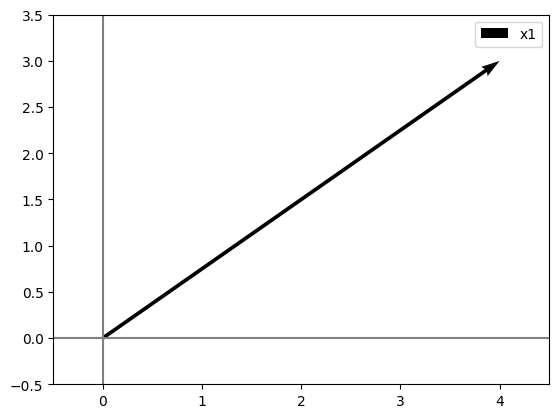

In [16]:
x1 = np.array([4,3])

plot_vectors([x1], ['x1'])

We can also visualize multiple vectors at the same time:

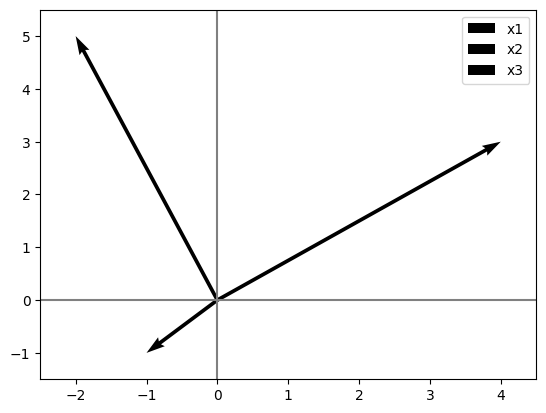

In [18]:
x1 = np.array([4,3])
x2 = np.array([-2,5])
x3 = np.array([-1,-1])

plot_vectors([x1, x2, x3], ['x1', 'x2', 'x3'])

### For-Schleife

Die `for`-Schleife eignet sich dafür, um über einzelne Elemente einer Liste zu iterieren:

In [27]:
ls = [6, 2, 'ab', [5,4]]

for x in ls:
    print(x)

6
2
ab
[5, 4]


Anstatt über eine Liste, können wir auch über eine Zahlenreihe iterieren. Dies geht mit der Funktion `range()`. `range(n)` gibt dabei die Zahlen $0,…,n-1$ aus.

In [29]:
for i in range(5):
    print(i)

0
1
2
3
4


 Möchten wir einen anderen Startpunkt der Zahlenreihe, geht das mit dem Befehl `range(m,n)`. Hier werden nun die Zahlen $m,…,n$ ausgegeben. Hierfür muss $m < n$ sein, ansonsten wird keine Zahl ausgegeben.

In [32]:
for i in range(2,5):
    print(i)

for i in range(5,2):
    print(i)

2
3
4


### Beispiel: Summe der Zahlen von 1 bis n 

Wir wollen die sehr bekannte Formel für die Summe der Zahlen von $1$ bis $n$ validieren:
$$ \sum_{i=1}^n i = \frac{n(n-1)}{2}$$

In [28]:
n = 100
my_sum = 0
for i in range(1,n+1):  # inklusive der 100
    my_sum += i
    
print("Summe: ", my_sum)
print("Formel:", n*(n+1)/2)

Summe:  5050
Formel: 5050.0


### Simultane Iteration über mehrere Listen: zip()

Bei der simultanen Iteration über zwei (oder mehrere) Listen existiert eine vorgefertigte Python-Funktion namens <code>zip()</code>, die uns zudem Sonderfälle wie unterschiedlich lange Listen abnimmt. zip ist hierbei als Reißverschluss zu übersetzen und zu verstehen.

In [ ]:
list1 = [1, 2, 3, 4, 5]
list2 = [-1, -2, -3, -4, -5]

for a,b in zip(list1, list2):
    print(a,b)

1 -1
2 -2
3 -3
4 -4
5 -5
